In [84]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Annotated

In [85]:
load_dotenv()

True

In [86]:
generator_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    max_tokens=1024,
    reasoning_effort="low",     
)
evaluator_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    max_tokens=512,
    reasoning_effort="low",
)
optimzer_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    max_tokens=1024,
    reasoning_effort="low",
)

In [87]:
class EvaluatorOutput(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(description="Judge whether tweet is approved or needs improvement")
    feedback: str = Field(description="One paragraph feedback related to the tweet")

In [88]:
evaluator_llm = evaluator_llm.with_structured_output(EvaluatorOutput, method="json_mode")

In [89]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str

    loop_count: int 
    max_iteration: int 

In [90]:
def generate_tweet(state: TweetState) -> dict:

    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages).content

    if not response or not response.strip():
        raise ValueError("Generator returned an empty tweet — check max_tokens/reasoning_effort.")

    return {"tweet": response}


In [91]:
def route_evaluation(state: TweetState) -> Literal["approved", "needs_improvement"]:
    if state["evaluation"] == "approved" or state["loop_count"] >= state["max_iteration"]:
        return "approved"
    else:
        return "needs_improvement"

In [92]:
def evaluate_tweet(state: TweetState) -> dict:

     # prompt
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['tweet']}"

    Use the criteria below to evaluate the tweet:

    1. Originality – Is this fresh, or have you seen it a hundred times before?  
    2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness – Is it short, sharp, and scroll-stopping?  
    4. Virality Potential – Would people retweet or share it?  
    5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

    ### Respond ONLY as a JSON object with this structure:
    {{
        "evaluation": "approved" or "needs_improvement",
        "feedback": "One paragraph explaining the strengths and weaknesses"
    }}
    """)
    ]


    response = evaluator_llm.invoke(messages)

    return {"evaluation": response.evaluation, "feedback": response.feedback}


In [93]:
def optimize_tweet(state: TweetState) -> dict:

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimzer_llm.invoke(messages).content
    iteration = state["loop_count"] + 1

    return {"tweet": response, "loop_count": iteration}


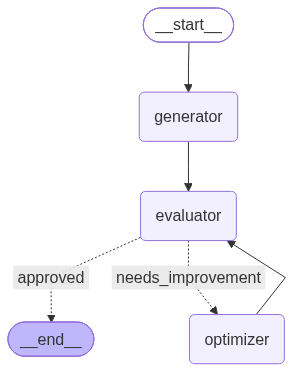

In [94]:
graph = StateGraph(TweetState)

graph.add_node("generator", generate_tweet)
graph.add_node("evaluator", evaluate_tweet)
graph.add_node("optimizer", optimize_tweet)

graph.add_edge(START, "generator")
graph.add_edge("generator", "evaluator")
graph.add_conditional_edges(
    "evaluator", 
    route_evaluation,
    {
        "approved": END,
        "needs_improvement": "optimizer"
    }
)
graph.add_edge("optimizer", "evaluator")

workflow = graph.compile()
workflow

In [98]:
input_state = {
    "topic": "Indian Railways",
    "loop_count": 1,
    "max_iteration" : 5
}

output_state = workflow.invoke(input_state)

output_state

{'topic': 'Indian Railways',
 'tweet': 'Indian Railways: where “on time” means the train will arrive at a time you can’t remember, and “coach” is a portable sauna that doubles as a 3‑seat family reunion. 🚂💨 #TrainLife #IndianRailways #TravelDiaries 😂🛤️',
 'evaluation': 'approved',
 'feedback': 'This tweet scores well on originality and humor, offering a fresh, relatable take on the quirks of Indian Railways with vivid imagery (“portable sauna” and “3‑seat family reunion”). Its punchiness is solid—short, sharp, and scroll‑stopping, with emojis and hashtags that enhance readability. The virality potential is high; commuters and travel enthusiasts will likely retweet. The format is correct: it stays under 280 characters, avoids a question‑answer structure, and does not end with a weak closing line. Overall, it’s a clean, shareable tweet that hits all the key criteria.',
 'loop_count': 1,
 'max_iteration': 5}